# Wine Price Prediction - Model Comparison

## Goal

Compare different regression models for predicting wine prices using the same dataset and evaluation setup.

Models to evaluate:
- Linear Regression
- Ridge Regression
- Decision Tree
- Random Forest
- CatBoost
- LightGBM
- XGBoost
- RealMLP
- TabM
- TabPFN
- TabICLv2

We will compare two feature configurations:
1. Tabular features only
2. Tabular + engineered features extracted from Description

## 1. Setup

Import the libraries needed for data handling, visualization, preprocessing, and model evaluation.

In [43]:
import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load Cleaned Dataset

Load the preprocessed wine dataset created in the previous preprocessing step.

In [44]:
df = pd.read_csv('../../data/processed/WineDataset_clean.csv')

print(f"Dataset shape: {df.shape}")
print(df.columns.tolist())

df.head(3)

Dataset shape: (1286, 12)
['Description', 'Capacity', 'Grape', 'Closure', 'Country', 'Type', 'ABV', 'Region', 'Style', 'Vintage', 'Price_clean', 'Price_log']


,Description,Capacity,Grape,Closure,Country,Type,ABV,Region,Style,Vintage,Price_clean,Price_log
0,We asked some of our most prized winemakers wo...,75CL,Tempranillo,Natural Cork,Spain,Red,14.0,Unknown,Rich & Juicy,NV,9.99,2.396986
1,This really does what it says on the tin. It’s...,75CL,Chardonnay,Natural Cork,USA,White,13.5,California,Rich & Toasty,2021,15.99,2.832625
2,Oyster Bay has been an award-winning gold-stan...,75CL,Sauvignon Blanc,Screwcap,New Zealand,White,13.0,Marlborough,Crisp & Zesty,2022,12.49,2.601949


## 3. Feature Engineering

Create additional interpretable features from the wine descriptions using regex-based text extraction.

These features capture information such as awards, critic scores, organic production, oak aging, prestige, and description length.

In [45]:
# --- Engineered features from Description ---

df['has_award'] = df['Description'].str.contains(
    r'award|medal|trophy',
    case=False,
    regex=True
).astype(int)

df['critic_score'] = df['Description'].str.extract(
    r'(\d{2})\s*points'
).astype(float)

df['has_critic_score'] = df['critic_score'].notna().astype(int)
df['critic_score'] = df['critic_score'].fillna(0)

df['is_organic'] = df['Description'].str.contains(
    r'organic|biodynamic',
    case=False,
    regex=True
).astype(int)

df['oak_aged'] = df['Description'].str.contains(
    r'oak',
    case=False,
    regex=True
).astype(int)

df['handpicked'] = df['Description'].str.contains(
    r'hand-?pick|hand-?harvest',
    case=False,
    regex=True
).astype(int)

df['has_history'] = df['Description'].str.contains(
    r'centur|founded|history|heritage|est(?:ablished)?.?\s*\d{4}',
    case=False,
    regex=True
).astype(int)

df['premium_classification'] = df['Description'].str.contains(
    r'grand cru|premier cru|gran reserva|cru class|classified',
    case=False,
    regex=True
).astype(int)

df['prestige_endorsement'] = df['Description'].str.contains(
    r'royal|queen|king|tsar|celebrity|state banquet',
    case=False,
    regex=True
).astype(int)

df['desc_length'] = df['Description'].str.split().str.len()

print("Engineered features created!")

Engineered features created!


## 4. Define Features and Target

Separate the available variables into:

- categorical features
- numerical features
- engineered features

The prediction target is `Price_log`, the log-transformed wine price.

In [46]:
cat_cols = [
    'Capacity',
    'Grape',
    'Closure',
    'Country',
    'Type',
    'Region',
    'Style',
    'Vintage'
]

num_cols = ['ABV']

eng_features = [
    'has_award',
    'has_critic_score',
    'critic_score',
    'is_organic',
    'oak_aged',
    'handpicked',
    'has_history',
    'premium_classification',
    'prestige_endorsement',
    'desc_length'
]

target = 'Price_log'

X_tabular = df[cat_cols + num_cols]
X_engineered = df[cat_cols + num_cols + eng_features]

y = df[target]

print("Tabular features:", X_tabular.shape)
print("Tabular + Engineered:", X_engineered.shape)
print("Target:", y.shape)

Tabular features: (1286, 9)
Tabular + Engineered: (1286, 19)
Target: (1286,)


## 5. Train-Test Split

Split the dataset into training and test sets.

The same split (`random_state=42`) will be used for all models to ensure a fair comparison.

In [47]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42
)

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print(f"Train size: {len(train_idx)}")
print(f"Test size: {len(test_idx)}")

Train size: 1028
Test size: 258


## 6. Preprocessing

Categorical features are converted using One-Hot Encoding, while numerical features are kept unchanged.

The same preprocessing is fitted only on the training data and then applied to the test data.

In [21]:
# --- Preprocessing for sklearn models ---

preprocessor = ColumnTransformer(transformers=[
    (
        'cat',
        OneHotEncoder(handle_unknown='ignore', sparse_output=True),
        cat_cols
    ),
    (
        'num',
        'passthrough',
        num_cols
    )
])

# Tabular only
X_train_tab = preprocessor.fit_transform(
    df.loc[train_idx, cat_cols + num_cols]
)

X_test_tab = preprocessor.transform(
    df.loc[test_idx, cat_cols + num_cols]
)

print("Tabular train shape:", X_train_tab.shape)
print("Tabular test shape:", X_test_tab.shape)

Tabular train shape: (1028, 291)
Tabular test shape: (258, 291)


### Add Engineered Features

The engineered numerical features are appended to the encoded tabular features.

This creates the second feature configuration used for model comparison.

In [22]:
import scipy.sparse as sp

X_train_eng = df.loc[train_idx, eng_features].values
X_test_eng = df.loc[test_idx, eng_features].values

X_train_combined = sp.hstack([
    X_train_tab,
    sp.csr_matrix(X_train_eng)
])

X_test_combined = sp.hstack([
    X_test_tab,
    sp.csr_matrix(X_test_eng)
])

print("Tabular + Engineered train shape:", X_train_combined.shape)
print("Tabular + Engineered test shape:", X_test_combined.shape)

Tabular + Engineered train shape: (1028, 301)
Tabular + Engineered test shape: (258, 301)


## 7. Evaluation Setup

All models are evaluated using the same metrics:

- **R²** — proportion of variance explained by the model
- **RMSE (log)** — prediction error on the log-transformed target
- **RMSE (£)** — prediction error converted back to the original price scale

Results from all models will be stored for later comparison.

In [23]:
def evaluate_model(name, feature_set, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)

    rmse_log = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    rmse_original = np.sqrt(
        mean_squared_error(
            np.expm1(y_true),
            np.expm1(y_pred)
        )
    )

    print(f"=== {name} | {feature_set} ===")
    print(f"R²: {r2:.4f}")
    print(f"RMSE (log): {rmse_log:.4f}")
    print(f"RMSE (£): {rmse_original:.2f}")
    print()

    return {
        'Model': name,
        'Features': feature_set,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_original
    }


results = []

# 8. Classical Regression Models

We first evaluate traditional regression models.

Each model is tested on:

1. Tabular features only
2. Tabular + engineered features

## 8.1 Linear Regression

Linear Regression provides a simple baseline and assumes a linear relationship between the input features and wine price.

In [24]:
from sklearn.linear_model import LinearRegression

# Tabular only
linear_tab = LinearRegression()
linear_tab.fit(X_train_tab, y_train)

pred_tab = linear_tab.predict(X_test_tab)

results.append(
    evaluate_model(
        "Linear Regression",
        "Tabular",
        y_test,
        pred_tab
    )
)

# Tabular + Engineered
linear_eng = LinearRegression()
linear_eng.fit(X_train_combined, y_train)

pred_eng = linear_eng.predict(X_test_combined)

results.append(
    evaluate_model(
        "Linear Regression",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== Linear Regression | Tabular ===
R²: 0.4607
RMSE (log): 0.4704
RMSE (£): 31.86

=== Linear Regression | Tabular + Engineered ===
R²: 0.4640
RMSE (log): 0.4690
RMSE (£): 31.40



### Observations

- Linear Regression performs relatively poorly, with R² around 0.46.
- Adding engineered features provides only a very small improvement.
- This suggests that the relationship between wine characteristics and price is not well captured by a simple unregularized linear model.

## 8.2 Ridge Regression

Ridge Regression extends Linear Regression by adding L2 regularization.

Regularization helps reduce overfitting, especially when One-Hot Encoding creates many correlated features.

In [25]:
from sklearn.linear_model import Ridge

# Tabular only
ridge_tab = Ridge(alpha=1.0)
ridge_tab.fit(X_train_tab, y_train)

pred_tab = ridge_tab.predict(X_test_tab)

results.append(
    evaluate_model(
        "Ridge Regression",
        "Tabular",
        y_test,
        pred_tab
    )
)

# Tabular + Engineered
ridge_eng = Ridge(alpha=1.0)
ridge_eng.fit(X_train_combined, y_train)

pred_eng = ridge_eng.predict(X_test_combined)

results.append(
    evaluate_model(
        "Ridge Regression",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== Ridge Regression | Tabular ===
R²: 0.6127
RMSE (log): 0.3986
RMSE (£): 22.37

=== Ridge Regression | Tabular + Engineered ===
R²: 0.6230
RMSE (log): 0.3933
RMSE (£): 22.01



### Observations

- Ridge Regression performs substantially better than ordinary Linear Regression.
- Adding engineered features improves R² from 0.6127 to 0.6230 and slightly reduces RMSE.
- Regularization appears beneficial for the high-dimensional One-Hot Encoded feature space.
- Ridge + Engineered is currently the best-performing model.

## 8.3 Decision Tree

Decision Tree Regression captures nonlinear relationships by recursively splitting the feature space.

Unlike linear models, it can model complex interactions between wine characteristics without assuming a linear relationship.

In [26]:
from sklearn.tree import DecisionTreeRegressor

# Tabular only
tree_tab = DecisionTreeRegressor(
    random_state=42
)

tree_tab.fit(X_train_tab, y_train)
pred_tab = tree_tab.predict(X_test_tab)

results.append(
    evaluate_model(
        "Decision Tree",
        "Tabular",
        y_test,
        pred_tab
    )
)

# Tabular + Engineered
tree_eng = DecisionTreeRegressor(
    random_state=42
)

tree_eng.fit(X_train_combined, y_train)
pred_eng = tree_eng.predict(X_test_combined)

results.append(
    evaluate_model(
        "Decision Tree",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== Decision Tree | Tabular ===
R²: 0.3531
RMSE (log): 0.5152
RMSE (£): 31.91

=== Decision Tree | Tabular + Engineered ===
R²: 0.2418
RMSE (log): 0.5577
RMSE (£): 39.98



### Observations

- A single Decision Tree performs considerably worse than Ridge Regression.
- Adding engineered features further decreases performance (R² 0.3531 → 0.2418).
- The poor test performance suggests that the unrestricted tree is likely overfitting the training data.
- This motivates testing ensemble tree methods such as Random Forest and gradient boosting.

## 8.4 Random Forest

Random Forest combines many decision trees and averages their predictions.

This usually reduces overfitting compared with a single Decision Tree and can capture nonlinear relationships between features and wine price.

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Tabular only
rf_tab = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_tab.fit(X_train_tab, y_train)
pred_tab = rf_tab.predict(X_test_tab)

results.append(
    evaluate_model(
        "Random Forest",
        "Tabular",
        y_test,
        pred_tab
    )
)

# Tabular + Engineered
rf_eng = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_eng.fit(X_train_combined, y_train)
pred_eng = rf_eng.predict(X_test_combined)

results.append(
    evaluate_model(
        "Random Forest",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== Random Forest | Tabular ===
R²: 0.6037
RMSE (log): 0.4032
RMSE (£): 26.66

=== Random Forest | Tabular + Engineered ===
R²: 0.6181
RMSE (log): 0.3958
RMSE (£): 26.96



### Observations

- Random Forest performs much better than a single Decision Tree, confirming that the ensemble reduces overfitting.
- Adding engineered features improves R² from 0.6037 to 0.6181.
- However, RMSE (£) slightly increases from £26.66 to £26.96, so the improvement is not consistent across both metrics.
- Ridge Regression + Engineered remains the best model so far (R² = 0.6230, RMSE = £22.01).

## 8.5 CatBoost

CatBoost is a gradient boosting algorithm with native support for categorical features.

Unlike the previous sklearn models, categorical variables are passed directly to CatBoost instead of being manually One-Hot Encoded.

In [28]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
# CatBoost feature sets

catboost_tab_cols = cat_cols + num_cols
catboost_eng_cols = cat_cols + num_cols + eng_features

X_train_cb_tab = df.loc[train_idx, catboost_tab_cols].copy()
X_test_cb_tab = df.loc[test_idx, catboost_tab_cols].copy()

X_train_cb_eng = df.loc[train_idx, catboost_eng_cols].copy()
X_test_cb_eng = df.loc[test_idx, catboost_eng_cols].copy()

print("Tabular:", X_train_cb_tab.shape)
print("Tabular + Engineered:", X_train_cb_eng.shape)

Tabular: (1028, 9)
Tabular + Engineered: (1028, 19)


In [30]:
from catboost import CatBoostRegressor

# Tabular only
cb_tab = CatBoostRegressor(
    random_seed=42,
    verbose=0
)

cb_tab.fit(
    X_train_cb_tab,
    y_train,
    cat_features=cat_cols
)

pred_tab = cb_tab.predict(X_test_cb_tab)

results.append(
    evaluate_model(
        "CatBoost",
        "Tabular",
        y_test,
        pred_tab
    )
)

=== CatBoost | Tabular ===
R²: 0.6537
RMSE (log): 0.3769
RMSE (£): 23.80



In [31]:
# Tabular + Engineered
cb_eng = CatBoostRegressor(
    random_seed=42,
    verbose=0
)

cb_eng.fit(
    X_train_cb_eng,
    y_train,
    cat_features=cat_cols
)

pred_eng = cb_eng.predict(X_test_cb_eng)

results.append(
    evaluate_model(
        "CatBoost",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== CatBoost | Tabular + Engineered ===
R²: 0.6514
RMSE (log): 0.3782
RMSE (£): 23.66



### Observations

- CatBoost achieves the highest R² so far: 0.6537 with tabular features.
- Adding engineered features slightly decreases R² (0.6537 → 0.6514), but slightly improves RMSE (£23.80 → £23.66).
- CatBoost clearly outperforms Random Forest and Decision Tree in terms of R².
- Ridge Regression still has the lowest RMSE (£22.01), while CatBoost explains more variance overall.

## 8.6 LightGBM

LightGBM is a gradient boosting framework optimized for efficient tree-based learning.

It supports categorical features directly, allowing us to evaluate the original tabular variables without manual One-Hot Encoding.

In [32]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from lightgbm import LGBMRegressor

# Prepare data for LightGBM
X_train_lgb_tab = df.loc[train_idx, cat_cols + num_cols].copy()
X_test_lgb_tab = df.loc[test_idx, cat_cols + num_cols].copy()

X_train_lgb_eng = df.loc[
    train_idx,
    cat_cols + num_cols + eng_features
].copy()

X_test_lgb_eng = df.loc[
    test_idx,
    cat_cols + num_cols + eng_features
].copy()

# Convert categorical columns to pandas category dtype
for col in cat_cols:
    X_train_lgb_tab[col] = X_train_lgb_tab[col].astype('category')
    X_test_lgb_tab[col] = X_test_lgb_tab[col].astype('category')

    X_train_lgb_eng[col] = X_train_lgb_eng[col].astype('category')
    X_test_lgb_eng[col] = X_test_lgb_eng[col].astype('category')

print("Tabular:", X_train_lgb_tab.shape)
print("Tabular + Engineered:", X_train_lgb_eng.shape)

Tabular: (1028, 9)
Tabular + Engineered: (1028, 19)


In [34]:
# Tabular only
lgb_tab = LGBMRegressor(
    random_state=42,
    verbosity=-1
)

lgb_tab.fit(
    X_train_lgb_tab,
    y_train
)

pred_tab = lgb_tab.predict(X_test_lgb_tab)

results.append(
    evaluate_model(
        "LightGBM",
        "Tabular",
        y_test,
        pred_tab
    )
)

=== LightGBM | Tabular ===
R²: 0.5929
RMSE (log): 0.4087
RMSE (£): 25.34



In [35]:
# Tabular + Engineered
lgb_eng = LGBMRegressor(
    random_state=42,
    verbosity=-1
)

lgb_eng.fit(
    X_train_lgb_eng,
    y_train
)

pred_eng = lgb_eng.predict(X_test_lgb_eng)

results.append(
    evaluate_model(
        "LightGBM",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== LightGBM | Tabular + Engineered ===
R²: 0.5685
RMSE (log): 0.4208
RMSE (£): 25.31



### Observations

- LightGBM achieves R² = 0.5929 using tabular features.
- Adding engineered features decreases performance to R² = 0.5685.
- Both LightGBM configurations perform worse than CatBoost and Ridge Regression.
- The engineered features do not benefit the default LightGBM configuration.

## 8.7 XGBoost

XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees sequentially.

For this baseline comparison, the One-Hot Encoded feature matrices created earlier are used.

In [36]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from xgboost import XGBRegressor

# Convert to CSR format
X_train_tab_xgb = X_train_tab.tocsr()
X_test_tab_xgb = X_test_tab.tocsr()

X_train_combined_xgb = X_train_combined.tocsr()
X_test_combined_xgb = X_test_combined.tocsr()

In [38]:
# Tabular only

xgb_tab = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

xgb_tab.fit(
    X_train_tab_xgb,
    y_train
)

pred_tab = xgb_tab.predict(X_test_tab_xgb)

results.append(
    evaluate_model(
        "XGBoost",
        "Tabular",
        y_test,
        pred_tab
    )
)

=== XGBoost | Tabular ===
R²: 0.6332
RMSE (log): 0.3879
RMSE (£): 24.98



In [39]:
# Tabular + Engineered

xgb_eng = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

xgb_eng.fit(
    X_train_combined_xgb,
    y_train
)

pred_eng = xgb_eng.predict(X_test_combined_xgb)

results.append(
    evaluate_model(
        "XGBoost",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== XGBoost | Tabular + Engineered ===
R²: 0.6123
RMSE (log): 0.3988
RMSE (£): 25.98



### Observations

- XGBoost performs well with the tabular features, reaching R² = 0.6332.
- Adding engineered features decreases performance to R² = 0.6123 and increases RMSE.
- XGBoost outperforms Random Forest and LightGBM, but remains below CatBoost in terms of R².
- The engineered features do not improve the default XGBoost configuration.

# 9. Modern Tabular Neural Models

The following models are designed specifically for tabular data and use neural-network-based architectures.

We first evaluate RealMLP and TabM using the same train-test split and feature configurations.

## 9.1 RealMLP

RealMLP is a neural network model designed specifically for tabular data.

It uses tuned default settings and performs its own preprocessing of numerical and categorical features.

In [40]:
%pip install pytabkit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from pytabkit import RealMLP_TD_Regressor

# RealMLP feature sets
X_train_real_tab = df.loc[
    train_idx,
    cat_cols + num_cols
].copy()

X_test_real_tab = df.loc[
    test_idx,
    cat_cols + num_cols
].copy()

X_train_real_eng = df.loc[
    train_idx,
    cat_cols + num_cols + eng_features
].copy()

X_test_real_eng = df.loc[
    test_idx,
    cat_cols + num_cols + eng_features
].copy()

print("Tabular:", X_train_real_tab.shape)
print("Tabular + Engineered:", X_train_real_eng.shape)

Tabular: (1028, 9)
Tabular + Engineered: (1028, 19)


In [42]:
#tabular only
realmlp_tab = RealMLP_TD_Regressor(
    random_state=42,
    verbosity=0
)

realmlp_tab.fit(
    X_train_real_tab,
    y_train
)

pred_tab = realmlp_tab.predict(X_test_real_tab)

results.append(
    evaluate_model(
        "RealMLP",
        "Tabular",
        y_test,
        pred_tab
    )
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [ ]:
#engineered
realmlp_eng = RealMLP_TD_Regressor(
    random_state=42,
    verbosity=0
)

realmlp_eng.fit(
    X_train_real_eng,
    y_train
)

pred_eng = realmlp_eng.predict(X_test_real_eng)

results.append(
    evaluate_model(
        "RealMLP",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_epochs=256` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== RealMLP | Tabular + Engineered ===
R²: 0.6059
RMSE (log): 0.4021
RMSE (£): 22.41



### Observations

- RealMLP achieves R² = 0.6270 using tabular features.
- Adding engineered features decreases R² to 0.6059.
- However, the engineered configuration improves RMSE substantially, from £24.03 to £22.41.
- RealMLP is competitive with Ridge and XGBoost, but CatBoost still achieves the highest R² so far.

## 9.2 TabM

TabM is a neural model for tabular data based on parameter-efficient ensembling.

For the baseline comparison, we use the default TabM configuration provided by PyTabKit.

In [ ]:
from pytabkit import TabM_D_Regressor

# TabM feature sets
X_train_tabm_tab = df.loc[
    train_idx,
    cat_cols + num_cols
].copy()

X_test_tabm_tab = df.loc[
    test_idx,
    cat_cols + num_cols
].copy()

X_train_tabm_eng = df.loc[
    train_idx,
    cat_cols + num_cols + eng_features
].copy()

X_test_tabm_eng = df.loc[
    test_idx,
    cat_cols + num_cols + eng_features
].copy()

print("Tabular:", X_train_tabm_tab.shape)
print("Tabular + Engineered:", X_train_tabm_eng.shape)

Tabular: (1028, 9)
Tabular + Engineered: (1028, 19)


In [ ]:
# tabular only
tabm_tab = TabM_D_Regressor(
    random_state=42,
    verbosity=0
)

tabm_tab.fit(
    X_train_tabm_tab,
    y_train
)

pred_tab = tabm_tab.predict(X_test_tabm_tab)

results.append(
    evaluate_model(
        "TabM",
        "Tabular",
        y_test,
        pred_tab
    )
)

=== TabM | Tabular ===
R²: 0.6456
RMSE (log): 0.3813
RMSE (£): 21.66



In [ ]:
# engineered
tabm_eng = TabM_D_Regressor(
    random_state=42,
    verbosity=0
)

tabm_eng.fit(
    X_train_tabm_eng,
    y_train
)

pred_eng = tabm_eng.predict(X_test_tabm_eng)

results.append(
    evaluate_model(
        "TabM",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== TabM | Tabular + Engineered ===
R²: 0.6411
RMSE (log): 0.3837
RMSE (£): 22.90



### Observations

- TabM achieves strong performance with tabular features: R² = 0.6456.
- It also achieves the lowest RMSE so far at £21.66.
- Adding engineered features slightly decreases both R² and RMSE performance.
- CatBoost still has the highest R² (0.6537), while TabM currently has the best RMSE (£21.66).

# 10. Tabular Foundation Models

We now evaluate pretrained foundation models designed specifically for tabular data.

Unlike the previous models, these models learn general patterns from large amounts of pretraining data and can be applied directly to new tabular regression tasks.

## 10.1 TabPFN

TabPFN is a pretrained foundation model for tabular data.

For regression, we use the official TabPFN implementation with the current default pretrained model. Raw pandas DataFrames are passed directly to the model, since TabPFN handles categorical features and preprocessing internally.

In [ ]:
%pip install --upgrade tabpfn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tabpfn

print("TabPFN version:", tabpfn.__version__)

TabPFN version: 9.0.0


In [51]:
# TabPFN feature sets

X_train_pfn_tab = df.loc[
    train_idx,
    cat_cols + num_cols
].copy()

X_test_pfn_tab = df.loc[
    test_idx,
    cat_cols + num_cols
].copy()

X_train_pfn_eng = df.loc[
    train_idx,
    cat_cols + num_cols + eng_features
].copy()

X_test_pfn_eng = df.loc[
    test_idx,
    cat_cols + num_cols + eng_features
].copy()

# Explicitly mark categorical columns
for col in cat_cols:
    X_train_pfn_tab[col] = X_train_pfn_tab[col].astype("category")
    X_test_pfn_tab[col] = X_test_pfn_tab[col].astype("category")

    X_train_pfn_eng[col] = X_train_pfn_eng[col].astype("category")
    X_test_pfn_eng[col] = X_test_pfn_eng[col].astype("category")

print("Tabular:", X_train_pfn_tab.shape)
print("Tabular + Engineered:", X_train_pfn_eng.shape)

Tabular: (1028, 9)
Tabular + Engineered: (1028, 19)


In [48]:
import os
import getpass

os.environ["TABPFN_TOKEN"] = getpass.getpass(
    "Enter your TabPFN API key: "
)

print("TabPFN token set for this session.")

TabPFN token set for this session.


In [50]:
from tabpfn import TabPFNRegressor


In [ ]:
tabpfn_tab = TabPFNRegressor(
    device="cpu",
    random_state=42
)

tabpfn_tab.fit(
    X_train_pfn_tab,
    y_train
)

pred_tab = tabpfn_tab.predict(
    X_test_pfn_tab
)

results.append(
    evaluate_model(
        "TabPFN",
        "Tabular",
        y_test,
        pred_tab
    )
)

NameError: name 'X_train_pfn_tab' is not defined

In [ ]:
# Tabular + Engineered

tabpfn_eng = TabPFNRegressor(
    device="cpu",
    random_state=42
)

tabpfn_eng.fit(
    X_train_pfn_eng,
    y_train
)

pred_eng = tabpfn_eng.predict(
    X_test_pfn_eng
)

results.append(
    evaluate_model(
        "TabPFN",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== TabPFN | Tabular + Engineered ===
R²: 0.6896
RMSE (log): 0.3569
RMSE (£): 23.10



### Observations

- TabPFN achieves the strongest R² performance in the benchmark so far.
- Adding engineered features slightly improves R² from 0.6870 to 0.6896.
- However, RMSE on the original price scale increases from £21.93 to £23.10.
- This suggests that the engineered features improve overall variance explanation, but lead to larger errors for some individual predictions.
- TabPFN + Engineered currently has the highest R², while TabM + Tabular still has the lowest RMSE (£21.66).

## 10.2 TabICLv2

TabICLv2 is a pretrained tabular foundation model for classification and regression.

It uses in-context learning and is designed to achieve strong performance without task-specific hyperparameter tuning.

Categorical and numerical features are passed directly to the model without manual One-Hot Encoding.

In [ ]:
%pip install tabicl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from tabicl import TabICLRegressor

print("TabICLv2 imported successfully!")

TabICLv2 imported successfully!


In [ ]:
# TabICLv2 feature sets

X_train_ticl_tab = df.loc[
    train_idx,
    cat_cols + num_cols
].copy()

X_test_ticl_tab = df.loc[
    test_idx,
    cat_cols + num_cols
].copy()

X_train_ticl_eng = df.loc[
    train_idx,
    cat_cols + num_cols + eng_features
].copy()

X_test_ticl_eng = df.loc[
    test_idx,
    cat_cols + num_cols + eng_features
].copy()

print("Tabular:", X_train_ticl_tab.shape)
print("Tabular + Engineered:", X_train_ticl_eng.shape)

Tabular: (1028, 9)
Tabular + Engineered: (1028, 19)


In [ ]:
#tabular only
tabicl_tab = TabICLRegressor()

tabicl_tab.fit(
    X_train_ticl_tab,
    y_train
)

pred_tab = tabicl_tab.predict(
    X_test_ticl_tab
)

results.append(
    evaluate_model(
        "TabICLv2",
        "Tabular",
        y_test,
        pred_tab
    )
)

=== TabICLv2 | Tabular ===
R²: 0.5975
RMSE (log): 0.4064
RMSE (£): 23.39



In [ ]:
# Tabular + Engineered

tabicl_eng = TabICLRegressor()

tabicl_eng.fit(
    X_train_ticl_eng,
    y_train
)

pred_eng = tabicl_eng.predict(
    X_test_ticl_eng
)

results.append(
    evaluate_model(
        "TabICLv2",
        "Tabular + Engineered",
        y_test,
        pred_eng
    )
)

=== TabICLv2 | Tabular + Engineered ===
R²: 0.6224
RMSE (log): 0.3936
RMSE (£): 22.91



### Observations

- TabICLv2 achieves R² = 0.5975 using tabular features.
- Adding engineered features improves R² to 0.6224 and reduces RMSE from £23.39 to £22.91.
- Unlike several other models, TabICLv2 benefits clearly from the engineered description features.
- Its performance is competitive, but remains below the strongest TabPFN, CatBoost, and TabM results.

# 11. Initial Benchmark Comparison

All evaluated models are compared using the same train-test split and evaluation metrics.

The comparison includes both:
- Tabular features only
- Tabular + engineered description features

## 11.1 Results Table

The complete benchmark results are summarized below and ranked by R² score.

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)

results_df

,Model,Features,R2,RMSE_log,RMSE_GBP
0,TabPFN,Tabular + Engineered,0.689610,0.356854,23.099066
1,TabPFN,Tabular,0.687030,0.358334,21.927579
2,CatBoost,Tabular,0.653732,0.376914,23.796240
3,CatBoost,Tabular + Engineered,0.651360,0.378203,23.657643
4,TabM,Tabular,0.645634,0.381296,21.657603
5,TabM,Tabular + Engineered,0.641099,0.383729,22.895549
6,XGBoost,Tabular,0.633216,0.387920,24.981484
7,RealMLP,Tabular,0.626968,0.391210,24.031242
8,Ridge Regression,Tabular + Engineered,0.622994,0.393288,22.012594
9,TabICLv2,Tabular + Engineered,0.622373,0.393612,22.912950


## 11.2 Best Models by Metric

In [ ]:
best_r2 = results_df.loc[results_df['R2'].idxmax()]
best_rmse = results_df.loc[results_df['RMSE_GBP'].idxmin()]

print("Best R²:")
print(
    f"{best_r2['Model']} | {best_r2['Features']} "
    f"→ R² = {best_r2['R2']:.4f}"
)

print("\nBest RMSE (£):")
print(
    f"{best_rmse['Model']} | {best_rmse['Features']} "
    f"→ RMSE = £{best_rmse['RMSE_GBP']:.2f}"
)

Best R²:
TabPFN | Tabular + Engineered → R² = 0.6896

Best RMSE (£):
TabM | Tabular → RMSE = £21.66


## 11.3 R² Comparison

The following chart compares the R² scores of all model and feature-set combinations.

Higher R² indicates that the model explains a larger proportion of the variation in wine prices.

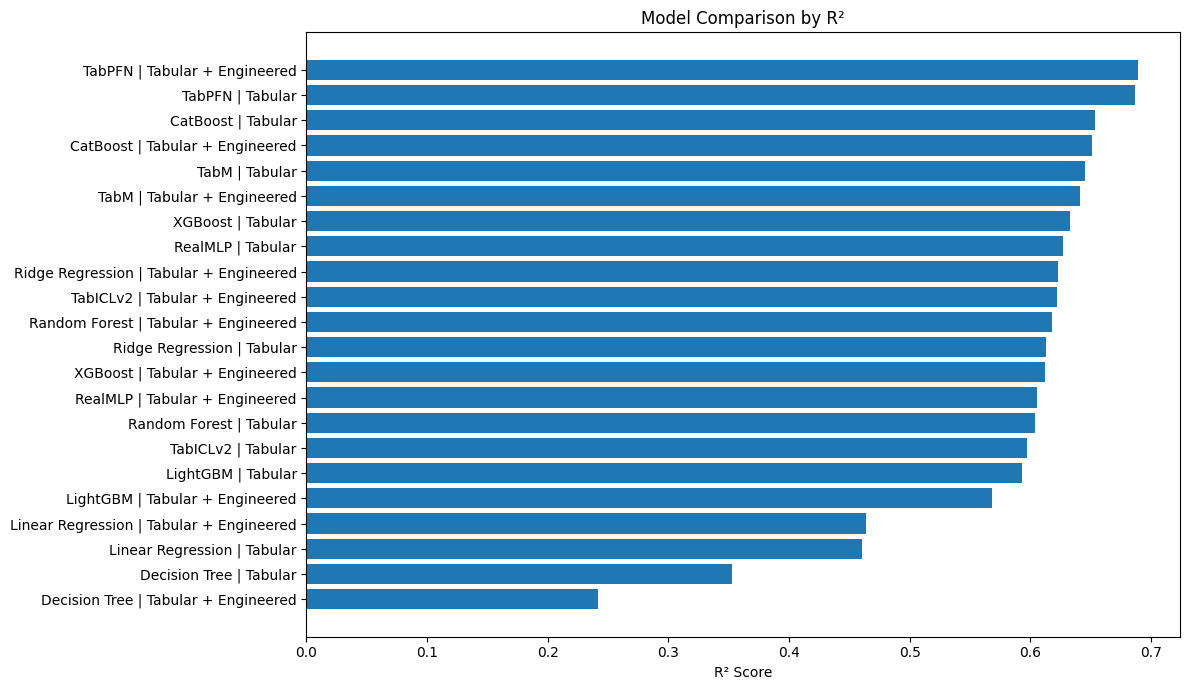

In [ ]:
plt.figure(figsize=(12, 7))

plot_df = results_df.sort_values('R2', ascending=True)

labels = (
    plot_df['Model']
    + ' | '
    + plot_df['Features']
)

plt.barh(labels, plot_df['R2'])

plt.xlabel('R² Score')
plt.title('Model Comparison by R²')
plt.tight_layout()
plt.show()

### Observations

- TabPFN achieves the strongest R² performance, reaching 0.6896 with engineered features.
- CatBoost and TabM follow with R² scores around 0.65.
- XGBoost, RealMLP, Ridge, and TabICLv2 form a competitive group around R² = 0.62–0.63.
- Linear Regression and a single Decision Tree perform substantially worse than the stronger ensemble, neural, and foundation models.

## 11.4 RMSE Comparison

RMSE is evaluated on the original price scale in pounds.

Lower RMSE indicates more accurate price predictions.

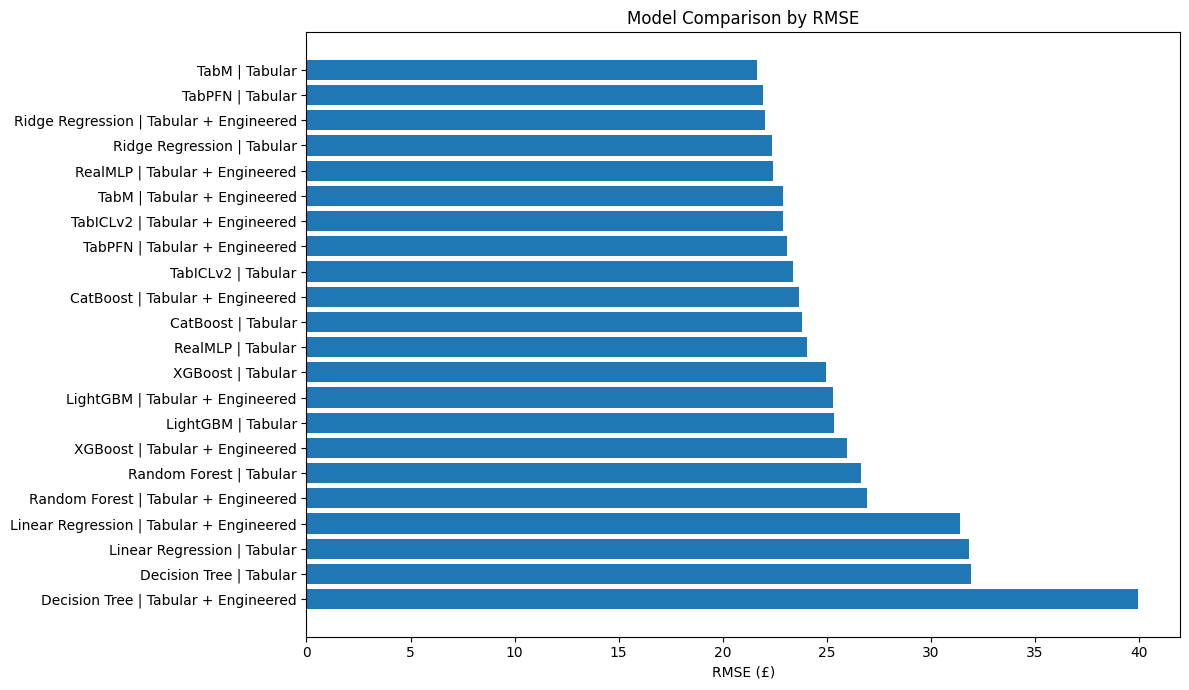

In [ ]:
plt.figure(figsize=(12, 7))

plot_df = results_df.sort_values('RMSE_GBP', ascending=False)

labels = (
    plot_df['Model']
    + ' | '
    + plot_df['Features']
)

plt.barh(labels, plot_df['RMSE_GBP'])

plt.xlabel('RMSE (£)')
plt.title('Model Comparison by RMSE')
plt.tight_layout()
plt.show()

### Observations

- TabM with tabular features achieves the lowest RMSE (£21.66).
- TabPFN with tabular features is very competitive at £21.93, followed closely by Ridge Regression + Engineered at £22.01.
- RealMLP and TabICLv2 also achieve relatively low RMSE values.
- TabPFN achieves the best R² but not the best RMSE, confirming that the two metrics capture different aspects of predictive performance.

## 11.5 Impact of Engineered Features

The engineered description features do not affect all models in the same way.

They improve some models, while reducing performance for others.

In [ ]:
comparison = results_df.pivot(
    index='Model',
    columns='Features',
    values=['R2', 'RMSE_GBP']
)

comparison

R2                        RMSE_GBP  \
Features            Tabular Tabular + Engineered    Tabular   
Model                                                         
CatBoost           0.653732             0.651360  23.796240   
Decision Tree      0.353081             0.241822  31.911927   
LightGBM           0.592871             0.568460  25.338534   
Linear Regression  0.460664             0.463954  31.855393   
Random Forest      0.603687             0.618150  26.659811   
RealMLP            0.626968             0.605909  24.031242   
Ridge Regression   0.612686             0.622994  22.365690   
TabICLv2           0.597527             0.622373  23.393968   
TabM               0.645634             0.641099  21.657603   
TabPFN             0.687030             0.689610  21.927579   
XGBoost            0.633216             0.612323  24.981484   

                                        
Features          Tabular + Engineered  
Model                                   
CatBoost                     23.657643  
Decision Tree                39.975331  
LightGBM                     25.312056  
Linear Regression            31.395987  
Random Forest                26.956635  
RealMLP                      22.405714  
Ridge Regression             22.012594  
TabICLv2                     22.912950  
TabM                         22.895549  
TabPFN                       23.099066  
XGBoost                      25.979047

### Observations

- Engineered features improve R² for Ridge Regression, Random Forest, TabICLv2, and slightly for TabPFN.
- For TabPFN, the R² improvement is small (0.6870 → 0.6896), while RMSE worsens (£21.93 → £23.10).
- Engineered features provide only a small overall change for CatBoost.
- They reduce R² for LightGBM, XGBoost, RealMLP, TabM, and Decision Tree.
- Overall, the usefulness of handcrafted text-derived features is strongly model-dependent and does not automatically translate into better generalization.

# 12. Initial Benchmark Summary

The initial benchmark shows that model choice has a substantial impact on wine price prediction.

- **TabPFN + Tabular + Engineered** achieves the highest R²: **0.6896**.
- **TabM + Tabular** achieves the lowest RMSE on the original price scale: **£21.66**.
- **TabPFN + Tabular** provides a strong balance between both metrics, with R² = **0.6870** and RMSE = **£21.93**.
- CatBoost remains the strongest conventional gradient boosting model in terms of R².
- Ridge Regression performs surprisingly well and benefits from the engineered description features.
- A single Decision Tree strongly underperforms ensemble and modern tabular methods.
- Modern neural and foundation models, particularly TabM and TabPFN, are highly competitive on this small tabular dataset.
- Engineered description features provide useful information for some models, but their effect is strongly model-dependent.

Overall, **TabPFN, TabM, and CatBoost** emerge as the strongest candidates for further validation. The next step is to evaluate model stability using cross-validation before performing targeted hyperparameter optimization.

# 13. Cross-Validation

The initial benchmark was based on a single 80/20 train-test split.

To evaluate whether the strongest results are stable across different subsets of the dataset, we now perform **5-fold cross-validation**.

The same folds are used for all models and feature configurations to ensure a fair comparison.

## 13.1 Cross-Validation Setup

We use 5-fold cross-validation with shuffling and a fixed random state for reproducibility.

Unlike the initial benchmark, all available samples are used across the five folds.

In [ ]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

df_train_cv = df.loc[train_idx].copy()

print("5-fold cross-validation configured.")
print("CV dataset shape:", df_train_cv.shape)

5-fold cross-validation configured.


## 13.2 Models Selected for Cross-Validation

Based on the initial benchmark, the strongest and most informative candidates are selected for further validation:

- **TabPFN** — highest R² in the initial benchmark
- **TabM** — lowest RMSE on the original price scale
- **CatBoost** — strongest conventional gradient boosting model
- **Ridge Regression** — strong regularized linear baseline

These models represent different modeling families and will first be evaluated without additional hyperparameter tuning.

## 13.3 Ridge Regression

Ridge Regression is evaluated first as a fast and strong baseline.

The One-Hot Encoder is fitted separately within each training fold to prevent information leakage from the validation fold.

In [ ]:
# tabular only
from sklearn.pipeline import Pipeline

ridge_cv_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(cv.split(df_train_cv), start=1):

    train_fold = df_train_cv.iloc[train_fold_idx]
    val_fold = df_train_cv.iloc[val_fold_idx]

    X_train_fold = train_fold[cat_cols + num_cols]
    X_val_fold = val_fold[cat_cols + num_cols]

    y_train_fold = train_fold[target]
    y_val_fold = val_fold[target]

    fold_preprocessor = ColumnTransformer(transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        ),
        (
            'num',
            'passthrough',
            num_cols
        )
    ])

    model = Pipeline([
        ('preprocessor', fold_preprocessor),
        ('model', Ridge(alpha=1.0))
    ])

    model.fit(X_train_fold, y_train_fold)
    pred = model.predict(X_val_fold)

    r2 = r2_score(y_val_fold, pred)

    rmse_log = np.sqrt(
        mean_squared_error(y_val_fold, pred)
    )

    rmse_gbp = np.sqrt(
        mean_squared_error(
            np.expm1(y_val_fold),
            np.expm1(pred)
        )
    )

    ridge_cv_results.append({
        'Fold': fold,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_gbp
    })

ridge_cv_tab = pd.DataFrame(ridge_cv_results)

ridge_cv_tab

,Fold,R2,RMSE_log,RMSE_GBP
0,1,0.612685,0.398629,22.365793
1,2,0.637192,0.429499,35.609036
2,3,0.663209,0.381527,21.361166
3,4,0.623488,0.444230,29.009828
4,5,0.537756,0.403927,16.521093


### Cross-Validation Summary

In [ ]:
ridge_tab_summary = {
    'Model': 'Ridge Regression',
    'Features': 'Tabular',
    'R2_mean': ridge_cv_tab['R2'].mean(),
    'R2_std': ridge_cv_tab['R2'].std(),
    'RMSE_log_mean': ridge_cv_tab['RMSE_log'].mean(),
    'RMSE_log_std': ridge_cv_tab['RMSE_log'].std(),
    'RMSE_GBP_mean': ridge_cv_tab['RMSE_GBP'].mean(),
    'RMSE_GBP_std': ridge_cv_tab['RMSE_GBP'].std()
}

ridge_tab_summary

{'Model': 'Ridge Regression',
 'Features': 'Tabular',
 'R2_mean': np.float64(0.6148660776772408),
 'R2_std': np.float64(0.04706515603280662),
 'RMSE_log_mean': np.float64(0.4115621758520495),
 'RMSE_log_std': np.float64(0.025082858218918307),
 'RMSE_GBP_mean': np.float64(24.973383276130615),
 'RMSE_GBP_std': np.float64(7.4279680053905865)}

### Observations

- Ridge Regression achieves a mean cross-validation R² of approximately 0.615.
- R² is relatively stable across folds, although one fold drops to around 0.54.
- The original-scale RMSE varies considerably between folds, indicating sensitivity to expensive wines and the skewed price distribution.
- The cross-validation result is close to the initial single-split Ridge baseline, suggesting that the original result was reasonably representative.

In [ ]:
ridge_eng_cv_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(cv.split(df_train_cv), start=1):

    train_fold = df_train_cv.iloc[train_fold_idx]
    val_fold = df_train_cv.iloc[val_fold_idx]   

    X_train_fold = train_fold[cat_cols + num_cols + eng_features]
    X_val_fold = val_fold[cat_cols + num_cols + eng_features]

    y_train_fold = train_fold[target]
    y_val_fold = val_fold[target]

    fold_preprocessor = ColumnTransformer(transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        ),
        (
            'num',
            'passthrough',
            num_cols + eng_features
        )
    ])

    model = Pipeline([
        ('preprocessor', fold_preprocessor),
        ('model', Ridge(alpha=1.0))
    ])

    model.fit(X_train_fold, y_train_fold)
    pred = model.predict(X_val_fold)

    r2 = r2_score(y_val_fold, pred)

    rmse_log = np.sqrt(
        mean_squared_error(y_val_fold, pred)
    )

    rmse_gbp = np.sqrt(
        mean_squared_error(
            np.expm1(y_val_fold),
            np.expm1(pred)
        )
    )

    ridge_eng_cv_results.append({
        'Fold': fold,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_gbp
    })

ridge_cv_eng = pd.DataFrame(ridge_eng_cv_results)

ridge_cv_eng

,Fold,R2,RMSE_log,RMSE_GBP
0,1,0.622921,0.393326,22.009620
1,2,0.627450,0.435227,35.991246
2,3,0.650577,0.388616,21.682982
3,4,0.622318,0.444920,28.868573
4,5,0.547619,0.399594,16.271428


In [ ]:
ridge_eng_summary = {
    'Model': 'Ridge Regression',
    'Features': 'Tabular + Engineered',
    'R2_mean': ridge_cv_eng['R2'].mean(),
    'R2_std': ridge_cv_eng['R2'].std(),
    'RMSE_log_mean': ridge_cv_eng['RMSE_log'].mean(),
    'RMSE_log_std': ridge_cv_eng['RMSE_log'].std(),
    'RMSE_GBP_mean': ridge_cv_eng['RMSE_GBP'].mean(),
    'RMSE_GBP_std': ridge_cv_eng['RMSE_GBP'].std()
}

ridge_eng_summary

{'Model': 'Ridge Regression',
 'Features': 'Tabular + Engineered',
 'R2_mean': np.float64(0.6141769659208006),
 'R2_std': np.float64(0.03896712595433614),
 'RMSE_log_mean': np.float64(0.4123365593054092),
 'RMSE_log_std': np.float64(0.02584587955929867),
 'RMSE_GBP_mean': np.float64(24.96476980813642),
 'RMSE_GBP_std': np.float64(7.614132838576624)}

### Observations

- Ridge Regression shows nearly identical cross-validation performance with and without the engineered features.
- The mean R² remains around 0.615 for both feature configurations.
- The engineered features slightly reduce the variability of R² across folds, but do not improve the average predictive performance.
- This suggests that the improvement observed in the initial single train-test split was not robust across different data partitions.

## 13.4 CatBoost

CatBoost is evaluated using its native handling of categorical features.

The model is trained separately within each cross-validation fold using the same five folds as the previous experiments.

In [ ]:
from catboost import CatBoostRegressor

catboost_cv_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(cv.split(df_train_cv), start=1):

    train_fold = df_train_cv.iloc[train_fold_idx]
    val_fold = df_train_cv.iloc[val_fold_idx]

    X_train_fold = train_fold[cat_cols + num_cols].copy()
    X_val_fold = val_fold[cat_cols + num_cols].copy()

    y_train_fold = train_fold[target]
    y_val_fold = val_fold[target]

    model = CatBoostRegressor(
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        cat_features=cat_cols
    )

    pred = model.predict(X_val_fold)

    r2 = r2_score(y_val_fold, pred)

    rmse_log = np.sqrt(
        mean_squared_error(y_val_fold, pred)
    )

    rmse_gbp = np.sqrt(
        mean_squared_error(
            np.expm1(y_val_fold),
            np.expm1(pred)
        )
    )

    catboost_cv_results.append({
        'Fold': fold,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_gbp
    })

catboost_cv_tab = pd.DataFrame(catboost_cv_results)

catboost_cv_tab

,Fold,R2,RMSE_log,RMSE_GBP
0,1,0.638548,0.385090,25.634748
1,2,0.640645,0.427450,35.294835
2,3,0.667246,0.379233,23.161725
3,4,0.676336,0.411875,28.832104
4,5,0.575617,0.387031,14.917870


In [ ]:
catboost_tab_summary = {
    'Model': 'CatBoost',
    'Features': 'Tabular',
    'R2_mean': catboost_cv_tab['R2'].mean(),
    'R2_std': catboost_cv_tab['R2'].std(),
    'RMSE_log_mean': catboost_cv_tab['RMSE_log'].mean(),
    'RMSE_log_std': catboost_cv_tab['RMSE_log'].std(),
    'RMSE_GBP_mean': catboost_cv_tab['RMSE_GBP'].mean(),
    'RMSE_GBP_std': catboost_cv_tab['RMSE_GBP'].std()
}

catboost_tab_summary

{'Model': 'CatBoost',
 'Features': 'Tabular',
 'R2_mean': np.float64(0.6396782615526307),
 'R2_std': np.float64(0.03940133888311665),
 'RMSE_log_mean': np.float64(0.3981359332887597),
 'RMSE_log_std': np.float64(0.020608864164175712),
 'RMSE_GBP_mean': np.float64(25.5682562902728),
 'RMSE_GBP_std': np.float64(7.491421509355189)}

### Observations

- CatBoost achieves a mean cross-validation R² of approximately 0.640.
- Its R² remains relatively stable across folds, with most folds between 0.64 and 0.68.
- The original-scale RMSE varies more strongly across folds, reflecting the influence of high-priced wines.
- Compared with Ridge Regression, CatBoost achieves a higher mean R² while showing a similar level of variability.

In [ ]:
catboost_eng_cv_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(cv.split(df_train_cv), start=1):

    train_fold = df_train_cv.iloc[train_fold_idx]
    val_fold = df_train_cv.iloc[val_fold_idx]

    X_train_fold = train_fold[
        cat_cols + num_cols + eng_features
    ].copy()

    X_val_fold = val_fold[
        cat_cols + num_cols + eng_features
    ].copy()

    y_train_fold = train_fold[target]
    y_val_fold = val_fold[target]

    model = CatBoostRegressor(
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        cat_features=cat_cols
    )

    pred = model.predict(X_val_fold)

    r2 = r2_score(y_val_fold, pred)

    rmse_log = np.sqrt(
        mean_squared_error(y_val_fold, pred)
    )

    rmse_gbp = np.sqrt(
        mean_squared_error(
            np.expm1(y_val_fold),
            np.expm1(pred)
        )
    )

    catboost_eng_cv_results.append({
        'Fold': fold,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_gbp
    })

catboost_cv_eng = pd.DataFrame(catboost_eng_cv_results)

catboost_cv_eng

,Fold,R2,RMSE_log,RMSE_GBP
0,1,0.661940,0.372420,24.868094
1,2,0.640434,0.427575,36.514459
2,3,0.644464,0.392001,22.694893
3,4,0.672213,0.414490,28.438665
4,5,0.574764,0.387420,15.618463


In [ ]:
catboost_eng_summary = {
    'Model': 'CatBoost',
    'Features': 'Tabular + Engineered',
    'R2_mean': catboost_cv_eng['R2'].mean(),
    'R2_std': catboost_cv_eng['R2'].std(),
    'RMSE_log_mean': catboost_cv_eng['RMSE_log'].mean(),
    'RMSE_log_std': catboost_cv_eng['RMSE_log'].std(),
    'RMSE_GBP_mean': catboost_cv_eng['RMSE_GBP'].mean(),
    'RMSE_GBP_std': catboost_cv_eng['RMSE_GBP'].std()
}

catboost_eng_summary

{'Model': 'CatBoost',
 'Features': 'Tabular + Engineered',
 'R2_mean': np.float64(0.6387631236537303),
 'R2_std': np.float64(0.03803687116658232),
 'RMSE_log_mean': np.float64(0.3987812317342536),
 'RMSE_log_std': np.float64(0.022055704099447803),
 'RMSE_GBP_mean': np.float64(25.626914801464846),
 'RMSE_GBP_std': np.float64(7.677665832532494)}

### Observations

- CatBoost shows almost identical cross-validation performance with and without the engineered features.
- The mean R² remains around 0.64 for both feature configurations.
- Adding engineered features does not improve either R² or RMSE on average.
- This suggests that CatBoost already captures most of the useful predictive structure from the original tabular features.

## 13.5 TabM

TabM is evaluated using its native tabular-data processing.

The same five cross-validation folds are used to assess whether its strong initial benchmark performance is stable across different data partitions.

In [ ]:
from pytabkit import TabM_D_Regressor

tabm_cv_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(cv.split( ), start=1):

    train_fold = df_train_cv.iloc[train_fold_idx]
    val_fold = df_train_cv.iloc[val_fold_idx]

    X_train_fold = train_fold[
        cat_cols + num_cols
    ].copy()

    X_val_fold = val_fold[
        cat_cols + num_cols
    ].copy()

    y_train_fold = train_fold[target]
    y_val_fold = val_fold[target]

    model = TabM_D_Regressor(
        random_state=42,
        verbosity=0
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    pred = model.predict(
        X_val_fold
    )

    r2 = r2_score(y_val_fold, pred)

    rmse_log = np.sqrt(
        mean_squared_error(
            y_val_fold,
            pred
        )
    )

    rmse_gbp = np.sqrt(
        mean_squared_error(
            np.expm1(y_val_fold),
            np.expm1(pred)
        )
    )

    tabm_cv_results.append({
        'Fold': fold,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_gbp
    })

tabm_cv_tab = pd.DataFrame(tabm_cv_results)

tabm_cv_tab

,Fold,R2,RMSE_log,RMSE_GBP
0,1,0.649654,0.379127,23.157520
1,2,0.631577,0.432809,35.924803
2,3,0.619002,0.405795,21.372454
3,4,0.626634,0.442370,28.983576
4,5,0.530531,0.407072,17.015133


In [ ]:
tabm_tab_summary = {
    'Model': 'TabM',
    'Features': 'Tabular',
    'R2_mean': tabm_cv_tab['R2'].mean(),
    'R2_std': tabm_cv_tab['R2'].std(),
    'RMSE_log_mean': tabm_cv_tab['RMSE_log'].mean(),
    'RMSE_log_std': tabm_cv_tab['RMSE_log'].std(),
    'RMSE_GBP_mean': tabm_cv_tab['RMSE_GBP'].mean(),
    'RMSE_GBP_std': tabm_cv_tab['RMSE_GBP'].std()
}

tabm_tab_summary

{'Model': 'TabM',
 'Features': 'Tabular',
 'R2_mean': np.float64(0.611479571596852),
 'R2_std': np.float64(0.04663744521952713),
 'RMSE_log_mean': np.float64(0.41343455989219874),
 'RMSE_log_std': np.float64(0.024942333912216758),
 'RMSE_GBP_mean': np.float64(25.29069702109974),
 'RMSE_GBP_std': np.float64(7.333307747193557)}

### Observations

- TabM achieves a mean cross-validation R² of approximately 0.611.
- Its performance varies noticeably across folds, with R² ranging from about 0.53 to 0.65.
- The mean original-scale RMSE is substantially higher than the value observed in the initial single train-test split.
- This suggests that TabM's strong initial RMSE result was sensitive to the particular data split and is less stable across different partitions.

In [ ]:
tabm_eng_cv_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(cv.split(df_train_cv), start=1):

    train_fold = df_train_cv.iloc[train_fold_idx]
    val_fold = df_train_cv.iloc[val_fold_idx]

    X_train_fold = train_fold[
        cat_cols + num_cols + eng_features
    ].copy()

    X_val_fold = val_fold[
        cat_cols + num_cols + eng_features
    ].copy()

    y_train_fold = train_fold[target]
    y_val_fold = val_fold[target]

    model = TabM_D_Regressor(
        random_state=42,
        verbosity=0
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    pred = model.predict(
        X_val_fold
    )

    r2 = r2_score(y_val_fold, pred)

    rmse_log = np.sqrt(
        mean_squared_error(
            y_val_fold,
            pred
        )
    )

    rmse_gbp = np.sqrt(
        mean_squared_error(
            np.expm1(y_val_fold),
            np.expm1(pred)
        )
    )

    tabm_eng_cv_results.append({
        'Fold': fold,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_gbp
    })

tabm_cv_eng = pd.DataFrame(tabm_eng_cv_results)

tabm_cv_eng

,Fold,R2,RMSE_log,RMSE_GBP
0,1,0.658951,0.374063,22.797355
1,2,0.628037,0.434884,35.730285
2,3,0.647274,0.390448,20.750941
3,4,0.622654,0.444722,29.431068
4,5,0.535381,0.404963,16.895048


In [ ]:
tabm_eng_summary = {
    'Model': 'TabM',
    'Features': 'Tabular + Engineered',
    'R2_mean': tabm_cv_eng['R2'].mean(),
    'R2_std': tabm_cv_eng['R2'].std(),
    'RMSE_log_mean': tabm_cv_eng['RMSE_log'].mean(),
    'RMSE_log_std': tabm_cv_eng['RMSE_log'].std(),
    'RMSE_GBP_mean': tabm_cv_eng['RMSE_GBP'].mean(),
    'RMSE_GBP_std': tabm_cv_eng['RMSE_GBP'].std()
}

tabm_eng_summary

{'Model': 'TabM',
 'Features': 'Tabular + Engineered',
 'R2_mean': np.float64(0.6184593897229114),
 'R2_std': np.float64(0.048685973048843076),
 'RMSE_log_mean': np.float64(0.4098160248675847),
 'RMSE_log_std': np.float64(0.029680501265360537),
 'RMSE_GBP_mean': np.float64(25.120939296157),
 'RMSE_GBP_std': np.float64(7.471556416996333)}

### Observations

- Adding the engineered features slightly improves TabM's average cross-validation performance.
- Mean R² increases from approximately 0.612 to 0.618, while both RMSE metrics decrease slightly.
- However, the improvement is small relative to the variability across folds.
- This suggests that the engineered features may provide some additional signal for TabM, but the effect is not strong or consistently large.

## 13.6 TabPFN

TabPFN is evaluated using the same five cross-validation folds.

Because TabPFN handles tabular preprocessing internally, categorical features are passed directly and explicitly marked as categorical.


In [ ]:
from tabpfn import TabPFNRegressor

tabpfn_cv_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(cv.split(df_train_cv), start=1):

    train_fold = df_train_cv.iloc[train_fold_idx]
    val_fold = df_train_cv.iloc[val_fold_idx]

    X_train_fold = train_fold[
        cat_cols + num_cols
    ].copy()

    X_val_fold = val_fold[
        cat_cols + num_cols
    ].copy()

    # Explicitly mark categorical columns
    for col in cat_cols:
        X_train_fold[col] = X_train_fold[col].astype("category")
        X_val_fold[col] = X_val_fold[col].astype("category")

    y_train_fold = train_fold[target]
    y_val_fold = val_fold[target]

    model = TabPFNRegressor(
        device="cpu",
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    pred = model.predict(
        X_val_fold
    )

    r2 = r2_score(y_val_fold, pred)

    rmse_log = np.sqrt(
        mean_squared_error(
            y_val_fold,
            pred
        )
    )

    rmse_gbp = np.sqrt(
        mean_squared_error(
            np.expm1(y_val_fold),
            np.expm1(pred)
        )
    )

    tabpfn_cv_results.append({
        'Fold': fold,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_gbp
    })

tabpfn_cv_tab = pd.DataFrame(tabpfn_cv_results)

tabpfn_cv_tab

,Fold,R2,RMSE_log,RMSE_GBP
0,1,0.687172,0.358253,21.901007
1,2,0.698101,0.391791,34.768226
2,3,0.724229,0.345238,20.076210
3,4,0.691973,0.401803,28.148411
4,5,0.609058,0.371470,15.755037


In [ ]:
tabpfn_tab_summary = {
    'Model': 'TabPFN',
    'Features': 'Tabular',
    'R2_mean': tabpfn_cv_tab['R2'].mean(),
    'R2_std': tabpfn_cv_tab['R2'].std(),
    'RMSE_log_mean': tabpfn_cv_tab['RMSE_log'].mean(),
    'RMSE_log_std': tabpfn_cv_tab['RMSE_log'].std(),
    'RMSE_GBP_mean': tabpfn_cv_tab['RMSE_GBP'].mean(),
    'RMSE_GBP_std': tabpfn_cv_tab['RMSE_GBP'].std()
}

tabpfn_tab_summary

{'Model': 'TabPFN',
 'Features': 'Tabular',
 'R2_mean': np.float64(0.6821065618912368),
 'R2_std': np.float64(0.04327029976385502),
 'RMSE_log_mean': np.float64(0.3737108165631624),
 'RMSE_log_std': np.float64(0.023295293304855438),
 'RMSE_GBP_mean': np.float64(24.129778390821212),
 'RMSE_GBP_std': np.float64(7.430698176638424)}

### Observations

- TabPFN achieves the strongest cross-validation performance so far, with a mean R² of approximately 0.682.
- Performance is relatively consistent across folds, although the fifth fold is noticeably weaker.
- The strong R² observed in the initial benchmark is therefore supported by cross-validation.
- Original-scale RMSE still varies across folds, reflecting the influence of high-priced wines.

In [ ]:
tabpfn_eng_cv_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(cv.split(df_train_cv), start=1):

    train_fold = df_train_cv.iloc[train_fold_idx]
    val_fold = df_train_cv.iloc[val_fold_idx]

    X_train_fold = train_fold[
        cat_cols + num_cols + eng_features
    ].copy()

    X_val_fold = val_fold[
        cat_cols + num_cols + eng_features
    ].copy()

    # Explicitly mark categorical columns
    for col in cat_cols:
        X_train_fold[col] = X_train_fold[col].astype("category")
        X_val_fold[col] = X_val_fold[col].astype("category")

    y_train_fold = train_fold[target]
    y_val_fold = val_fold[target]

    model = TabPFNRegressor(
        device="cpu",
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    pred = model.predict(
        X_val_fold
    )

    r2 = r2_score(y_val_fold, pred)

    rmse_log = np.sqrt(
        mean_squared_error(
            y_val_fold,
            pred
        )
    )

    rmse_gbp = np.sqrt(
        mean_squared_error(
            np.expm1(y_val_fold),
            np.expm1(pred)
        )
    )

    tabpfn_eng_cv_results.append({
        'Fold': fold,
        'R2': r2,
        'RMSE_log': rmse_log,
        'RMSE_GBP': rmse_gbp
    })

tabpfn_cv_eng = pd.DataFrame(tabpfn_eng_cv_results)

tabpfn_cv_eng

,Fold,R2,RMSE_log,RMSE_GBP
0,1,0.689610,0.356854,23.099052
1,2,0.703026,0.388582,34.734276
2,3,0.716065,0.350311,20.346397
3,4,0.695371,0.399580,28.236153
4,5,0.612319,0.369917,15.761059


In [ ]:
tabpfn_eng_summary = {
    'Model': 'TabPFN',
    'Features': 'Tabular + Engineered',
    'R2_mean': tabpfn_cv_eng['R2'].mean(),
    'R2_std': tabpfn_cv_eng['R2'].std(),
    'RMSE_log_mean': tabpfn_cv_eng['RMSE_log'].mean(),
    'RMSE_log_std': tabpfn_cv_eng['RMSE_log'].std(),
    'RMSE_GBP_mean': tabpfn_cv_eng['RMSE_GBP'].mean(),
    'RMSE_GBP_std': tabpfn_cv_eng['RMSE_GBP'].std()
}

tabpfn_eng_summary

{'Model': 'TabPFN',
 'Features': 'Tabular + Engineered',
 'R2_mean': np.float64(0.6832783426896577),
 'R2_std': np.float64(0.0408857092810984),
 'RMSE_log_mean': np.float64(0.37304879984464545),
 'RMSE_log_std': np.float64(0.02082221942981168),
 'RMSE_GBP_mean': np.float64(24.43538721481444),
 'RMSE_GBP_std': np.float64(7.318854491415721)}

### Observations

- TabPFN remains the strongest model in cross-validation with both feature configurations.
- Adding engineered features produces only a very small increase in mean R², from approximately 0.682 to 0.683.
- RMSE on the log scale improves slightly, while original-scale RMSE becomes marginally worse.
- Overall, the engineered features do not provide a substantial or consistent advantage for TabPFN.

## 13.7 Cross-Validation Comparison

The cross-validation results from all selected models and feature configurations are summarized below.

Performance is reported as the mean and standard deviation across the five folds.

In [ ]:
cv_summary_df = pd.DataFrame([
    ridge_tab_summary,
    ridge_eng_summary,
    catboost_tab_summary,
    catboost_eng_summary,
    tabm_tab_summary,
    tabm_eng_summary,
    tabpfn_tab_summary,
    tabpfn_eng_summary
])

cv_summary_df = cv_summary_df.sort_values(
    by='R2_mean',
    ascending=False
).reset_index(drop=True)

cv_summary_df

,Model,Features,R2_mean,R2_std,RMSE_log_mean,RMSE_log_std,RMSE_GBP_mean,RMSE_GBP_std
0,TabPFN,Tabular + Engineered,0.683278,0.040886,0.373049,0.020822,24.435387,7.318854
1,TabPFN,Tabular,0.682107,0.043270,0.373711,0.023295,24.129778,7.430698
2,CatBoost,Tabular,0.639678,0.039401,0.398136,0.020609,25.568256,7.491422
3,CatBoost,Tabular + Engineered,0.638763,0.038037,0.398781,0.022056,25.626915,7.677666
4,TabM,Tabular + Engineered,0.618459,0.048686,0.409816,0.029681,25.120939,7.471556
5,Ridge Regression,Tabular,0.614866,0.047065,0.411562,0.025083,24.973383,7.427968
6,Ridge Regression,Tabular + Engineered,0.614177,0.038967,0.412337,0.025846,24.964770,7.614133
7,TabM,Tabular,0.611480,0.046637,0.413435,0.024942,25.290697,7.333308


### Observations

- TabPFN clearly achieves the strongest cross-validation performance among the evaluated models.
- TabPFN + Engineered obtains the highest mean R² (0.6833), while TabPFN + Tabular achieves the lowest mean RMSE on the original price scale (£24.13).
- The difference between the two TabPFN feature configurations is very small, suggesting that the engineered features provide only limited additional benefit.
- CatBoost is the strongest conventional gradient boosting model, with a mean R² of approximately 0.64.
- Ridge Regression and TabM perform similarly overall, with mean R² values around 0.61–0.62.
- TabM's very strong RMSE result from the initial single train-test split does not persist across cross-validation folds.
- Across all models, RMSE on the original price scale varies substantially between folds, indicating sensitivity to the distribution of high-priced wines.

## 13.8 Cross-Validation Summary

Five-fold cross-validation confirms that TabPFN is the strongest candidate for this dataset.

The initial benchmark result is therefore supported by evaluation across multiple data partitions rather than a single train-test split.

The engineered description features do not provide a large or consistently positive improvement. For TabPFN, they slightly improve mean R² and log-scale RMSE, while the original-scale RMSE is slightly better without them.

Overall, TabPFN should be prioritized for the next experimental stage, while CatBoost provides a strong conventional baseline for comparison.

# 14. Hyperparameter Tuning

After evaluating model stability with 5-fold cross-validation, we now perform targeted hyperparameter tuning on the strongest candidate models.

Hyperparameters are optimized only on the training portion of the original 80/20 split. The test set is not used during the tuning process.

The goal is to determine whether model-specific optimization can improve upon the baseline configurations.

## 14.1 Tuning Strategy

We begin with CatBoost because it was the strongest conventional model during cross-validation.

Since the engineered description features did not improve CatBoost's average cross-validation performance, tuning is first performed using the original tabular feature set.

R² is used as the primary model-selection metric, while log-scale and original-scale RMSE are also monitored.

In [ ]:
# Training data used for hyperparameter tuning
X_train_tune_cb = df.loc[
    train_idx,
    cat_cols + num_cols
].copy()

X_test_tune_cb = df.loc[
    test_idx,
    cat_cols + num_cols
].copy()

y_train_tune = df.loc[train_idx, target]
y_test_tune = df.loc[test_idx, target]

print("Tuning train:", X_train_tune_cb.shape)
print("Test:", X_test_tune_cb.shape)

Tuning train: (1028, 9)
Test: (258, 9)


In [ ]:
from sklearn.metrics import make_scorer

def rmse_gbp_metric(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(
            np.expm1(y_true),
            np.expm1(y_pred)
        )
    )

rmse_gbp_scorer = make_scorer(
    rmse_gbp_metric,
    greater_is_better=False
)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

catboost_tuning_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0,
    thread_count=-1
)

catboost_param_space = {
    'iterations': [300, 500, 800, 1200],
    'depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.02, 0.03, 0.05, 0.08, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'random_strength': [0, 0.5, 1, 2]
}

scoring = {
    'R2': 'r2',
    'RMSE_log': 'neg_root_mean_squared_error',
    'RMSE_GBP': rmse_gbp_scorer
}

catboost_search = RandomizedSearchCV(
    estimator=catboost_tuning_model,
    param_distributions=catboost_param_space,
    n_iter=8,
    scoring=scoring,
    refit='R2',
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1,
    return_train_score=False
)

catboost_search.fit(
    X_train_tune_cb,
    y_train_tune,
    cat_features=cat_cols
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre...42, verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [4, 5, ...], 'iterations': [300, 500, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.02, 0.03, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'R2': 'r2', 'RMSE_GBP': make_scorer(r...hod='predict'), 'RMSE_log': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'R2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :

In [ ]:
print("Best parameters:")
print(catboost_search.best_params_)

print("\nBest CV R²:")
print(catboost_search.best_score_)

Best parameters:
{'random_strength': 1, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 1200, 'depth': 6}

Best CV R²:
0.6337505206161204


In [ ]:
best_catboost = catboost_search.best_estimator_

pred_tuned_cb = best_catboost.predict(
    X_test_tune_cb
)

tuned_cb_result = evaluate_model(
    "CatBoost Tuned",
    "Tabular",
    y_test_tune,
    pred_tuned_cb
)

tuned_cb_result

=== CatBoost Tuned | Tabular ===
R²: 0.6609
RMSE (log): 0.3730
RMSE (£): 24.02



{'Model': 'CatBoost Tuned',
 'Features': 'Tabular',
 'R2': 0.660903977246353,
 'RMSE_log': np.float64(0.37299071548442003),
 'RMSE_GBP': np.float64(24.02338057132616)}

### Observations

- Hyperparameter tuning provides a small improvement in CatBoost's test-set R², increasing it from approximately 0.654 to 0.661.
- Log-scale RMSE also improves slightly.
- However, RMSE on the original price scale increases marginally from about £23.80 to £24.02.
- Overall, the tuned configuration improves variance explanation slightly, but does not provide a clear improvement across all evaluation metrics.
- This suggests that the default CatBoost configuration was already highly competitive for this dataset.

In [ ]:
catboost_baseline_vs_tuned = pd.DataFrame([
    {
        'Model': 'CatBoost Baseline',
        'R2': 0.653732,
        'RMSE_log': 0.376914,
        'RMSE_GBP': 23.796240
    },
    {
        'Model': 'CatBoost Tuned',
        'R2': tuned_cb_result['R2'],
        'RMSE_log': tuned_cb_result['RMSE_log'],
        'RMSE_GBP': tuned_cb_result['RMSE_GBP']
    }
])

catboost_baseline_vs_tuned

,Model,R2,RMSE_log,RMSE_GBP
0,CatBoost Baseline,0.653732,0.376914,23.796240
1,CatBoost Tuned,0.660904,0.372991,24.023381


### Observations

- Hyperparameter tuning slightly improves CatBoost's R² from 0.6537 to 0.6609.
- Log-scale RMSE also improves slightly.
- However, RMSE on the original price scale becomes marginally worse.
- Overall, the tuned CatBoost configuration improves performance only modestly and does not outperform the baseline consistently across all metrics.
- This suggests that the default CatBoost configuration was already very competitive for this dataset.

## 14.3 Ridge Regression Tuning

Ridge Regression is tuned by optimizing its regularization strength (`alpha`).

Since the engineered features did not provide a meaningful improvement during cross-validation, tuning is performed using the original tabular feature set.

In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_tune_preprocessor = ColumnTransformer(transformers=[
    (
        'cat',
        OneHotEncoder(handle_unknown='ignore'),
        cat_cols
    ),
    (
        'num',
        'passthrough',
        num_cols
    )
])

ridge_tune_pipeline = Pipeline([
    ('preprocessor', ridge_tune_preprocessor),
    ('model', Ridge())
])

ridge_param_grid = {
    'model__alpha': [
        0.001,
        0.01,
        0.1,
        0.5,
        1,
        2,
        5,
        10,
        50,
        100
    ]
}

ridge_search = GridSearchCV(
    estimator=ridge_tune_pipeline,
    param_grid=ridge_param_grid,
    scoring=scoring,
    refit='R2',
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

ridge_search.fit(
    df.loc[train_idx, cat_cols + num_cols],
    y_train_tune
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'R2': 'r2', 'RMSE_GBP': make_scorer(r...hod='predict'), 'RMSE_log': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'R2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [ ]:
print("Best alpha:")
print(ridge_search.best_params_)

print("\nBest CV R²:")
print(ridge_search.best_score_)

Best alpha:
{'model__alpha': 2}

Best CV R²:
0.592177341302133


In [ ]:
best_ridge = ridge_search.best_estimator_

pred_tuned_ridge = best_ridge.predict(
    df.loc[test_idx, cat_cols + num_cols]
)

tuned_ridge_result = evaluate_model(
    "Ridge Tuned",
    "Tabular",
    y_test_tune,
    pred_tuned_ridge
)

tuned_ridge_result

=== Ridge Tuned | Tabular ===
R²: 0.6151
RMSE (log): 0.3974
RMSE (£): 23.26



{'Model': 'Ridge Tuned',
 'Features': 'Tabular',
 'R2': 0.6151141632739543,
 'RMSE_log': np.float64(0.3973769192024196),
 'RMSE_GBP': np.float64(23.262209833480906)}

### Observations

- Tuning Ridge Regression results in only a very small improvement in R².
- Log-scale RMSE also improves slightly.
- However, RMSE on the original price scale becomes worse.
- Overall, changing the regularization strength from the baseline does not provide a consistent improvement across all metrics.
- The baseline Ridge configuration was already close to the tuned solution.

In [ ]:
ridge_baseline_vs_tuned = pd.DataFrame([
    {
        'Model': 'Ridge Baseline',
        'R2': 0.612686,
        'RMSE_log': 0.398628,
        'RMSE_GBP': 22.365793
    },
    {
        'Model': 'Ridge Tuned',
        'R2': tuned_ridge_result['R2'],
        'RMSE_log': tuned_ridge_result['RMSE_log'],
        'RMSE_GBP': tuned_ridge_result['RMSE_GBP']
    }
])

ridge_baseline_vs_tuned

,Model,R2,RMSE_log,RMSE_GBP
0,Ridge Baseline,0.612686,0.398628,22.365793
1,Ridge Tuned,0.615114,0.397377,23.262210


## 14.4 TabPFN Optimization

TabPFN is a pretrained tabular foundation model and is not tuned in the same way as conventional models such as CatBoost or Ridge Regression.

The official regression tuning mechanism primarily calibrates the predictive distribution rather than substantially changing point predictions.

Since the current project evaluates models mainly using R² and RMSE, TabPFN is retained in its default pretrained configuration for the main point-prediction comparison.

In [ ]:
from tabpfn import TabPFNRegressor

tabpfn_calibrated = TabPFNRegressor(
    device="cpu",
    random_state=42,
    eval_metric="crps",
    tuning_config={
        "calibrate_temperature": True
    }
)

In [53]:
tabpfn_calibrated.fit(
    X_train_pfn_tab,
    y_train
)

pred_calibrated = tabpfn_calibrated.predict(
    X_test_pfn_tab
)

In [54]:
calibrated_result = evaluate_model(
    "TabPFN Calibrated",
    "Tabular",
    y_test,
    pred_calibrated
)

calibrated_result

=== TabPFN Calibrated | Tabular ===
R²: 0.6864
RMSE (log): 0.3587
RMSE (£): 21.99



{'Model': 'TabPFN Calibrated',
 'Features': 'Tabular',
 'R2': 0.6864453677535463,
 'RMSE_log': np.float64(0.3586685392401558),
 'RMSE_GBP': np.float64(21.985986424632067)}

### Observations

- Predictive-distribution calibration produces almost no change in TabPFN's point-prediction metrics.
- R² and both RMSE values remain virtually identical to the default TabPFN configuration.
- This is consistent with the purpose of temperature calibration, which primarily targets predictive-distribution quality rather than point-estimate accuracy.
- For the main R²/RMSE comparison, the default pretrained TabPFN configuration therefore remains the appropriate reference.

## 14.5 Tuned Model Comparison

The tuned and calibrated model variants are compared with their corresponding baseline configurations.

The goal is to determine whether model-specific optimization provides a meaningful improvement over the original settings.

In [56]:
phase3_comparison = pd.DataFrame([
    {
        'Model': 'CatBoost Baseline',
        'R2': 0.653732,
        'RMSE_log': 0.376914,
        'RMSE_GBP': 23.796240
    },
    {
        'Model': 'CatBoost Tuned',
        'R2': 0.660904,
        'RMSE_log': 0.372991,
        'RMSE_GBP': 24.023381
    },
    {
        'Model': 'Ridge Baseline',
        'R2': 0.612686,
        'RMSE_log': 0.398628,
        'RMSE_GBP': 22.365793
    },
    {
        'Model': 'Ridge Tuned',
        'R2': 0.615114,
        'RMSE_log': 0.397377,
        'RMSE_GBP': 23.262210
    },
    {
        'Model': 'TabPFN Baseline',
        'R2': 0.6870,
        'RMSE_log': 0.3583,
        'RMSE_GBP': 21.93
    },
    {
        'Model': 'TabPFN Calibrated',
        'R2': 0.686445,
        'RMSE_log': 0.358669,
        'RMSE_GBP': 21.985986
    }
])

phase3_comparison

,Model,R2,RMSE_log,RMSE_GBP
0,CatBoost Baseline,0.653732,0.376914,23.796240
1,CatBoost Tuned,0.660904,0.372991,24.023381
2,Ridge Baseline,0.612686,0.398628,22.365793
3,Ridge Tuned,0.615114,0.397377,23.262210
4,TabPFN Baseline,0.687000,0.358300,21.930000
5,TabPFN Calibrated,0.686445,0.358669,21.985986


### Observations

- CatBoost tuning slightly improves R² and log-scale RMSE, but slightly worsens RMSE on the original price scale.
- Ridge tuning produces only a very small improvement in R² and log-scale RMSE, while original-scale RMSE becomes worse.
- TabPFN calibration leaves point-prediction performance almost unchanged.
- None of the optimization steps produces a large and consistent improvement across all evaluation metrics.
- The default model configurations were therefore already strong for this dataset.

## 14.6 Hyperparameter Tuning Summary

Targeted hyperparameter tuning was performed for CatBoost and Ridge Regression, while TabPFN was evaluated with predictive-distribution calibration.

The experiments show that:

- CatBoost benefits only modestly from tuning.
- Ridge Regression is relatively insensitive to small changes in regularization strength.
- TabPFN calibration does not materially affect R² or RMSE, which is expected because calibration primarily targets predictive-distribution quality rather than point estimates.

Overall, hyperparameter optimization does not substantially change the ranking observed in the previous phases. TabPFN remains the strongest point-prediction model, while CatBoost remains the strongest conventional machine-learning baseline.

# 15. Final Model Selection

The experiments were conducted in three stages:

1. an initial benchmark across multiple model families,
2. 5-fold cross-validation of the strongest candidates,
3. targeted optimization of selected models.

Across these stages, TabPFN consistently provides the strongest overall point-prediction performance.

In the initial benchmark, TabPFN achieved the highest R², and its strong performance was confirmed during 5-fold cross-validation.

Predictive-distribution calibration did not materially improve its point-prediction metrics, indicating that the default pretrained configuration is already highly effective for this dataset.

## 15.1 Selected Model

**TabPFN with the original tabular feature set** is selected as the final point-prediction model.

The main reasons are:

- It achieves the strongest and most consistent R² performance.
- Its performance remains strong across cross-validation folds.
- It also achieves the lowest mean original-scale RMSE among the cross-validated candidate models.
- Engineered description features provide only a marginal improvement in R² while slightly worsening original-scale RMSE.
- Additional calibration does not materially improve point-prediction accuracy.

Therefore, the simpler tabular TabPFN configuration provides the best balance between predictive performance and model complexity.

## 15.2 Conventional Baseline

CatBoost is retained as the strongest conventional machine-learning baseline.

It achieves a mean cross-validation R² of approximately 0.64 and remains competitive after hyperparameter tuning.

Tuning slightly improves R² and log-scale RMSE, but does not consistently improve all metrics, suggesting that the default CatBoost configuration was already well suited to the dataset.

# 16. Conclusions

This project investigated wine price prediction using structured tabular information together with interpretable features extracted from free-text wine descriptions.

Several model families were evaluated, ranging from linear and tree-based methods to gradient boosting, neural tabular models, and pretrained tabular foundation models.

The main findings are:

- Model choice has a substantial influence on prediction quality.
- TabPFN consistently achieves the strongest overall performance.
- CatBoost provides the strongest conventional machine-learning baseline.
- A single train-test split can give an incomplete picture of model performance, as demonstrated by TabM's initially strong RMSE result.
- Five-fold cross-validation provides a more reliable assessment of model stability.
- Hand-engineered description features do not provide a consistent improvement across models.
- Hyperparameter tuning produces only modest gains for CatBoost and Ridge Regression.
- TabPFN predictive-distribution calibration does not materially change point-prediction accuracy.

Overall, the results suggest that pretrained tabular foundation models are particularly effective for this relatively small mixed-type dataset.

# 17. Future Work

Possible extensions of the current work include:

- further investigation of textual wine descriptions using TF-IDF or dense embeddings,
- dimensionality reduction of high-dimensional text embeddings before combining them with tabular features,
- more systematic uncertainty evaluation for probabilistic TabPFN predictions,
- analysis of prediction errors across different price ranges,
- investigation of the influence of rare or expensive wines on original-scale RMSE,
- evaluation on additional wine datasets to assess generalization beyond the current sample.